# 🍦 Ice Cream Sales Forecasting (Polynomial Regression)
**Objective:** Predict ice cream sales based on temperature. Since the relationship between temperature and ice cream sales is typically non-linear (sales grow exponentially as it gets hotter), a simple Linear Regression won't fit well. We will use a **Polynomial Regression Pipeline** to capture the underlying curve.

In [1]:
# 1. Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(" Libraries Imported Successfully")

 Libraries Imported Successfully


### 📂 Step 1: Load Data and Exploratory Data Analysis (EDA)
Let's load the dataset and visualize it to understand *why* we need Polynomial Regression instead of a straight line.

Dataset Shape: (49, 2)


,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


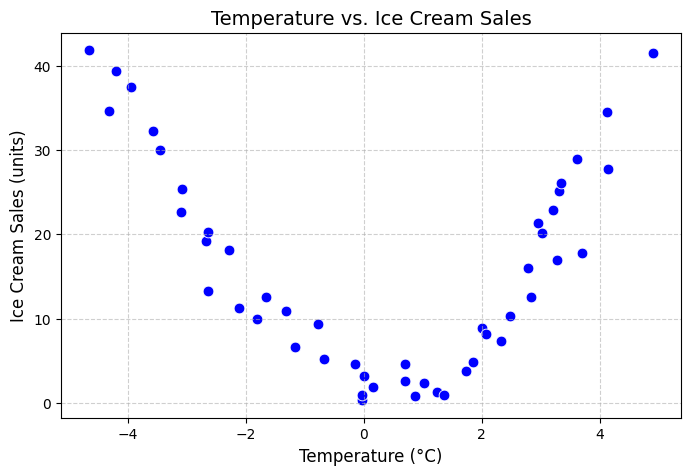

 Observation: The data points form a curve, not a straight line. This justifies the use of Polynomial Regression.


In [2]:
# Load Dataset
df = pd.read_csv('Ice_cream selling data.csv')

# Drop duplicates if any
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dataset Shape: {df.shape}")
display(df.head())

# EDA: Visualize the relationship
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Temperature (°C)', y='Ice Cream Sales (units)', data=df, color='blue', s=60)
plt.title('Temperature vs. Ice Cream Sales', fontsize=14)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Ice Cream Sales (units)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(" Observation: The data points form a curve, not a straight line. This justifies the use of Polynomial Regression.")


### ✂️ Step 2: Feature Separation & Train-Test Split

In [3]:
# Separate Features (X) and Target (y)
# Note: X must be a 2D array (DataFrame) for scikit-learn, y is 1D (Series)
X = df[['Temperature (°C)']] 
y = df['Ice Cream Sales (units)']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data Shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing Data Shape: X={X_test.shape}, y={y_test.shape}")

Training Data Shape: X=(39, 1), y=(39,)
Testing Data Shape: X=(10, 1), y=(10,)


### 🏗️ Step 3: Build the Polynomial ML Pipeline
We will create a pipeline that first standardizes the data, then generates polynomial features (squaring/cubing the inputs to create curves), and finally applies a Linear Regression model.

In [4]:
# Define Polynomial Degree (Degree 2 = Parabola/Curve)
degree = 2

# Create the Pipeline
poly_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),                        # Scale data for better performance
    ('poly_features', PolynomialFeatures(degree=degree)),# Generate polynomial and interaction features
    ('regressor', LinearRegression())                    # Train a linear model on the polynomial features
])

print(f" Polynomial Pipeline (Degree {degree}) Built Successfully")

 Polynomial Pipeline (Degree 2) Built Successfully


### 🚀 Step 4: Train, Evaluate, and Visualize the Model Performance

📊 Model Evaluation Metrics:
Mean Absolute Error (MAE): 3.23 Units
Root Mean Squared Error (RMSE): 3.86 Units
R-squared (R2) Score: 0.8431


C:\Users\ahmed\AppData\Local\Temp\ipykernel_19036\3324128352.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  X_smooth = np.linspace(X.min()[0], X.max()[0], 100).reshape(-1, 1)


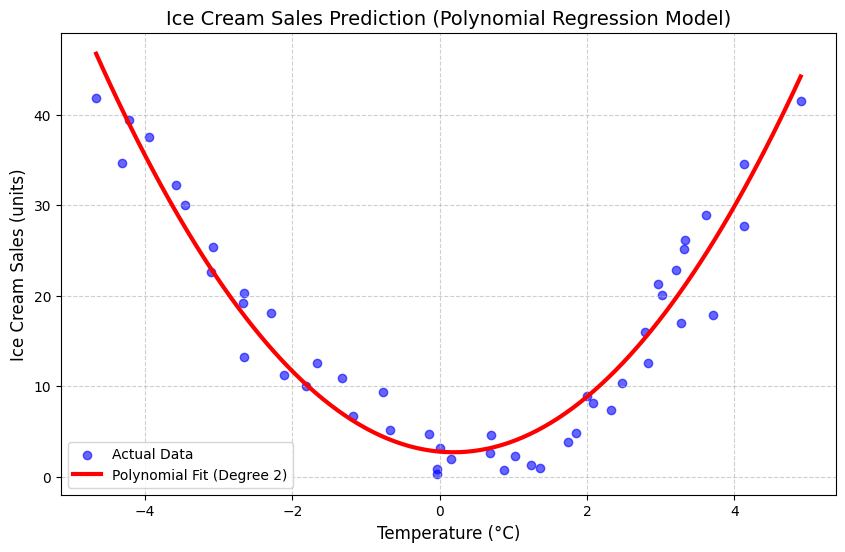

In [5]:
# Train the model
poly_pipeline.fit(X_train, y_train)

# Make Predictions
y_pred = poly_pipeline.predict(X_test)

# Evaluate the Model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📊 Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f} Units")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} Units")
print(f"R-squared (R2) Score: {r2:.4f}")

# ==========================================
# 📈 Visualizing the Final Polynomial Curve
# ==========================================
plt.figure(figsize=(10, 6))

# 1. Plot the original data points
plt.scatter(X, y, color='blue', label='Actual Data', alpha=0.6)

# 2. Generate a smooth curve for predictions
# We create a smooth range of temperatures from minimum to maximum
X_smooth = np.linspace(X.min()[0], X.max()[0], 100).reshape(-1, 1)
# Create a temporary dataframe to match feature names
X_smooth_df = pd.DataFrame(X_smooth, columns=['Temperature (°C)'])
# Predict sales for this smooth range using our trained pipeline
y_smooth_pred = poly_pipeline.predict(X_smooth_df)

# Plot the predicted curve
plt.plot(X_smooth_df, y_smooth_pred, color='red', linewidth=3, label=f'Polynomial Fit (Degree {degree})')

plt.title('Ice Cream Sales Prediction (Polynomial Regression Model)', fontsize=14)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Ice Cream Sales (units)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()